In [ ]:
# Импорт библиотек, потребующихся при работе.

import pandas as pd       # Работа с таблицами данных
import os                 # Работа с файловой системой
import plotly.express as px  # Интерактивные графики и диаграммы

import matplotlib.pyplot as plt  # Статичные графики и визуализация
import numpy as np         # Численные расчёты и массивы

from scipy import stats          # Статистические тесты и вероятностные распределения
from math import factorial       # Факториал числа для комбинаторных расчётов
from scipy.stats import binom    # Биномиальное распределение вероятностей
from math import sqrt            # Квадратный корень числа


In [ ]:
# Настройка отображения.
pd.set_option('display.max_rows', 500)

## Шаг 1. Загрузка данных

In [ ]:
# Загружаем датафреймы.
    data_users = pd.read_csv('/datasets/users_go.csv')
    data_rides = pd.read_csv('/datasets/rides_go.csv')
    data_subscriptions = pd.read_csv('/datasets/subscriptions_go.csv')


#### Выведем первые строки каждого набора данных и изучим общую информацию о каждом датафрейме.

In [ ]:
print(data_users.info()) # Посмотрим на структуру таблицы Users.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB
None


In [ ]:
data_users.sample(n=10) # Посмотрим на сами данные в таблице Users.

,user_id,name,age,city,subscription_type
1339,1340,Влад,32,Краснодар,free
325,326,Степан,30,Пятигорск,ultra
77,78,Ростислав,21,Пятигорск,ultra
680,681,Ярослава,30,Краснодар,ultra
621,622,Ярослава,24,Тюмень,ultra
1251,1252,Нелли,31,Краснодар,free
1121,1122,Степан,24,Краснодар,free
212,213,Елизавета,20,Ростов-на-Дону,ultra
1513,1514,Ева,25,Тюмень,free
1423,1424,Артур,29,Ростов-на-Дону,free


Таблица содержит информацию о 1565 пользователях. Пропущенных значений нет — все столбцы полностью заполнены. Типы данных определены корректно: числовые значения для идентификатора и возраста, строковые — для имени, города и типа подписки.

In [ ]:
print(data_rides.info()) # Посмотрим на структуру таблицы rides_go.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB
None


In [ ]:
data_rides.sample(n=10) # Посмотрим на сами данные в таблице rides_go.

,user_id,distance,duration,date
2461,262,3320.789866,10.115978,2021-02-06
13193,1190,4544.401687,16.487081,2021-01-25
7813,794,4605.746161,12.211492,2021-11-11
8318,835,2199.793598,20.285125,2021-02-17
11651,1075,2313.619102,14.712064,2021-11-06
1804,195,4448.399393,13.265537,2021-12-21
10779,1013,2984.534936,20.632300,2021-04-08
12465,1136,4572.953907,31.148577,2021-07-06
14462,1277,3114.283153,25.986999,2021-02-03
14496,1280,2953.348674,30.109175,2021-01-21


Таблица содержит 18 068 строк — каждая соответствует одной поездке. Пропущенных значений нет, все столбцы заполнены. Типы данных корректны: идентификатор — целое число, расстояние и длительность — вещественные числа, дата — строка. Для работы с датой может потребоваться изменить ее тип.


In [ ]:
print(data_subscriptions.info()) # Посмотрим на структуру таблицы subscriptions_go.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes
None


In [ ]:
data_subscriptions # Посмотрим на сами данные в таблице subscriptions_go.

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


Таблица содержит 2 строки — по одному тарифу: с подпиской и без неё. Все значения заполнены, пропусков нет. Типы данных заданы корректно: названия тарифов — строки, цены — целые числа.

## Шаг 2. Предобработка данных

### Приведем столбец date к типу даты в pandas.

In [ ]:
data_rides['date'] = data_rides['date'].astype('datetime64[s]')

In [ ]:
print(data_rides.info()) # Посмотрим на структуру таблицы после изменения типа столбца.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype        
---  ------    --------------  -----        
 0   user_id   18068 non-null  int64        
 1   distance  18068 non-null  float64      
 2   duration  18068 non-null  float64      
 3   date      18068 non-null  datetime64[s]
dtypes: datetime64[s](1), float64(2), int64(1)
memory usage: 564.8 KB
None


### Создадим новый столбец с номером месяца на основе столбца date.

### Проверим диапазон дат по годам.

In [ ]:
print(' Данные в датасете представлены за следующие года:' ,data_rides['date'].dt.year.unique())

 Данные в датасете представлены за следующие года: [2021]


In [ ]:
# После того как выяснили, что данные представлены за один год, можно переходить к созданию столбца с номером месяца.
data_rides['month']= data_rides['date'].dt.month

In [ ]:
data_rides.sample(n=10)

,user_id,distance,duration,date,month
17563,1500,3973.276807,11.946554,2021-07-30,7
3275,353,2925.639191,21.358969,2021-09-14,9
14091,1251,3368.768380,21.218789,2021-11-03,11
11173,1041,2009.602853,22.038411,2021-10-05,10
6503,700,1205.911290,9.782872,2021-02-10,2
16781,1441,2907.175359,10.306215,2021-10-26,10
8420,842,2252.711901,22.654480,2021-07-21,7
17973,1529,615.275107,5.272983,2021-02-01,2
7741,789,2608.968092,17.783630,2021-04-08,4
6756,716,1879.077846,12.249516,2021-12-23,12


### Проверяем наличие пропущенных значений.

In [ ]:
data_users.isnull().sum()# Пропущенные значения в таблице users.

,0
user_id,0
name,0
age,0
city,0
subscription_type,0


In [ ]:
data_rides.isnull().sum() # Пропущенные значения в таблице rides.

,0
user_id,0
distance,0
duration,0
date,0
month,0


In [ ]:
data_subscriptions.isnull().sum() # Пропущенные значения в таблице subscriptions.

,0
subscription_type,0
minute_price,0
start_ride_price,0
subscription_fee,0


Отсутствие результата при проверке было вполне предсказуемо, это стало ясно ещё на этапе изучения общих сведений о каждом датафрейме.

### Проверим наличие дубликатов в датафреймах.

In [ ]:
data_users.duplicated().sum()

np.int64(31)

In [ ]:
# Дубликаты есть, посмотрим на них.

In [ ]:
data_users[data_users.duplicated()].sort_values(by='user_id')

,user_id,name,age,city,subscription_type
1535,16,Амалия,27,Краснодар,ultra
1539,43,Стефания,22,Омск,ultra
1563,47,Юрий,28,Тюмень,ultra
1555,72,Никита,25,Москва,ultra
1549,108,Влада,29,Тюмень,ultra
1553,121,Алина,25,Пятигорск,ultra
1540,127,Павел,25,Пятигорск,ultra
1548,136,Марсель,25,Тюмень,ultra
1543,153,Герман,23,Москва,ultra
1542,204,Руслан,30,Пятигорск,ultra


In [ ]:
# Удалим дубликаты
data_users = data_users.drop_duplicates()

In [ ]:
# Посмотрим на результат удаления дубликатов.
print("Количество дубликатов в датафреме после удаления: ", data_users.duplicated().sum(),'\n')
print(data_users.info())

Количество дубликатов в датафреме после удаления:  0 

<class 'pandas.core.frame.DataFrame'>
Index: 1534 entries, 0 to 1533
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1534 non-null   int64 
 1   name               1534 non-null   object
 2   age                1534 non-null   int64 
 3   city               1534 non-null   object
 4   subscription_type  1534 non-null   object
dtypes: int64(2), object(3)
memory usage: 71.9+ KB
None


In [ ]:
data_rides.duplicated().sum()

np.int64(0)

In [ ]:
data_subscriptions.duplicated().sum()

np.int64(0)

В остальных датафреймах дубликатов не обнаружено.

### Проведем округление и проверку столбца 'distance'.

In [ ]:
# Посмотрим на данные до округления
display(data_rides['distance'].head(3))

# Округление расстояния
data_rides['distance'] = data_rides['distance'].round(2)
data_rides['distance'].head(3)

,distance
0,4409.919140
1,2617.592153
2,754.159807


,distance
0,4409.92
1,2617.59
2,754.16


In [ ]:
data_rides['distance'].describe()

,distance
count,18068.000000
mean,3070.659992
std,1116.831222
min,0.860000
25%,2543.227500
50%,3133.610000
75%,3776.220000
max,7211.010000


В колонке присутствуют аномальные значения min, max: 0,86 и 7211 метров, при среднем 3070.

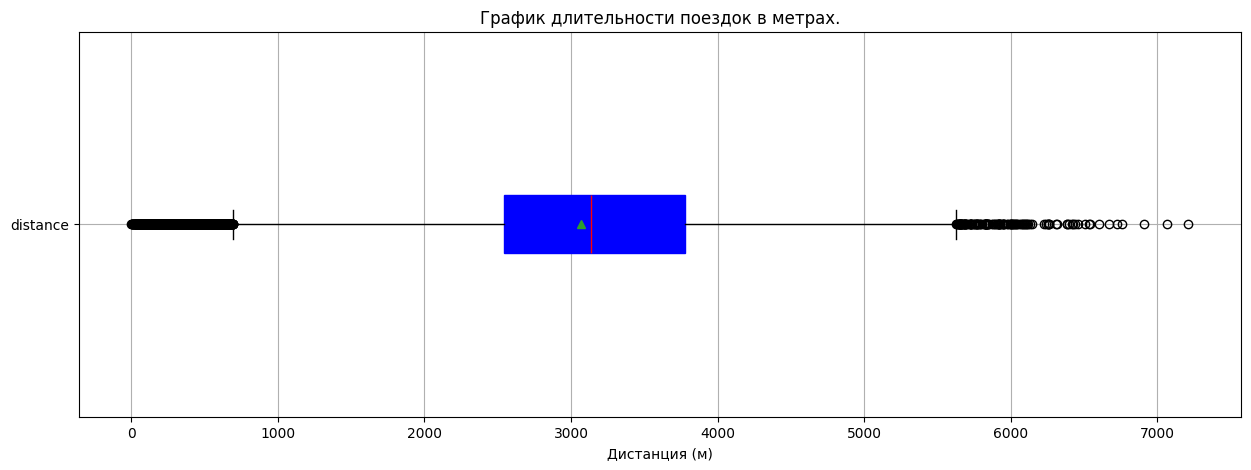

In [ ]:
# Построим график с усами для этого столбца.
data_rides['distance'].plot(kind='box',
                            figsize=(15, 5),
                            vert=False ,
                            grid=True,
                            showmeans=True,
                            meanline=False,
                            showfliers=True,
                            notch=False,
                            patch_artist=True,
                            color={'boxes': 'blue', 'whiskers': 'black', 'medians': 'red', 'caps': 'black'}
       )

plt.title('График длительности поездок в метрах.')
plt.xlabel('Дистанция (м)')
plt.show()


### Обобщенный вывод по разделу первичного анализа и предобработки данных.

Данные представлены в трёх таблицах и хорошо подготовлены для анализа:
* Всего в базе 1565 пользователей, пропусков и некорректных типов данных нет.
* Таблица поездок содержит 18 068 записей, каждая строка — отдельная поездка; данные полные, типы корректны, но столбец с датой требует преобразования.
* В таблице тарифов — 2 строки, отражающие оба типа подписки; структура корректна.
* Пропущенные значения и дубликаты отсутствуют, что подтверждено проверками.
* Добавлен столбец с месяцем поездки, и проверено, за какой год представлены данные.
* Округлены значения расстояния поездки.

## Шаг 3. Исследовательский анализ данных

 Опишем и визуализируем общую информацию о пользователях и их поездках.

### Частота встречаемости городов.

In [ ]:
#Сгруппируем исходную таблицу по городам и посчитаем количество пользователей в каждом.
table_city = data_users.groupby(by='city').agg(total_number = ('user_id', 'nunique')).reset_index().sort_values(by='total_number',ascending=False)
display(table_city)

,city,total_number
4,Пятигорск,219
0,Екатеринбург,204
5,Ростов-на-Дону,198
1,Краснодар,193
6,Сочи,189
3,Омск,183
7,Тюмень,180
2,Москва,168


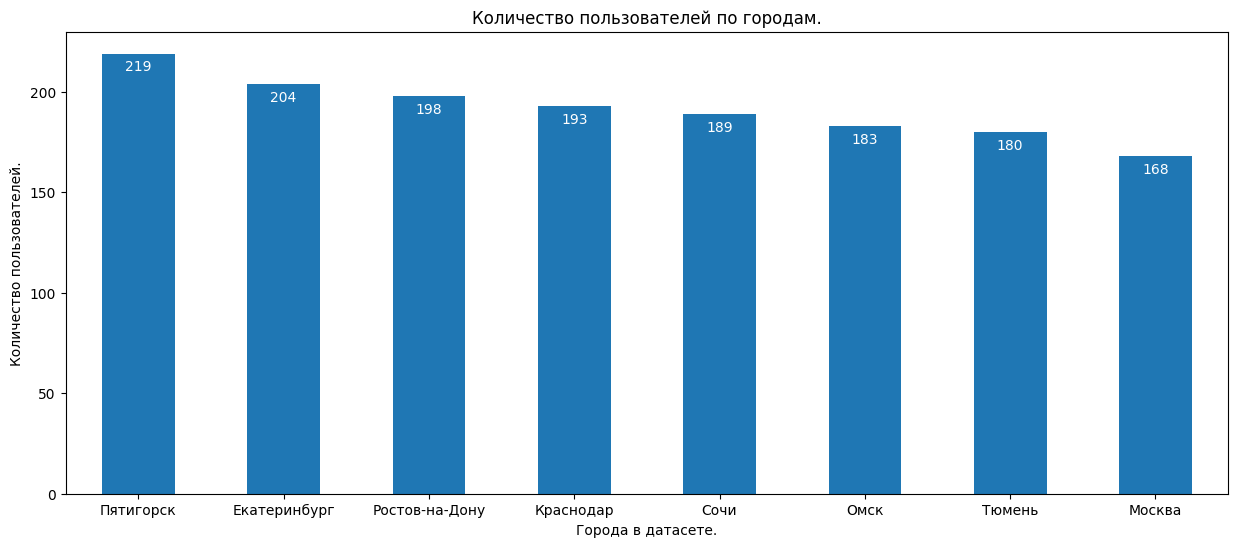

In [ ]:
ax = table_city.plot(x='city',
                      y='total_number',
                      kind='bar',
                      figsize=(15, 6),
                      title='Количество пользователей по городам.',
                      legend=False)

plt.xticks(rotation=0)
plt.xlabel('Города в датасете.')
plt.ylabel('Количество пользователей.')

for i, v in enumerate(table_city['total_number']):
    ax.text(i, v -10, str(v), ha='center', va='bottom',color='white')

plt.show()

Таблица и график наглядно показывает, что больше всего значений зафиксировано в Пятигорске (219), меньше всего — в Москве (168). Разброс между городами небольшой.

### Посмотрим на соотношение пользователей с подпиской и без подписки.

In [ ]:
# Сформируем таблицу пользователей с подпиской и без.
table_for_subscription_type = data_users.groupby(by='subscription_type')['user_id'].agg('count').reset_index().sort_values(by='user_id',ascending=False)

display(table_for_subscription_type)

,subscription_type,user_id
0,free,835
1,ultra,699


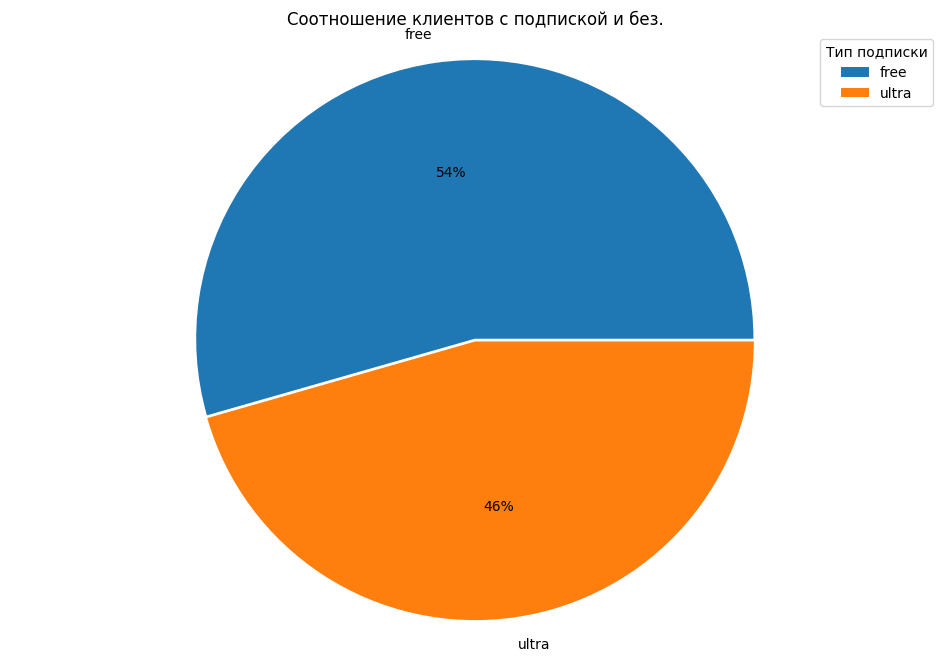

In [ ]:
# Построим диаграмму соотношения клиентов с подпиской и без.
table_for_subscription_type.plot (kind = 'pie',
                                  y='user_id',
                                  labels = ['free', 'ultra'],
                                  autopct='%1.0f%%',
                                  figsize = (12,8),
                                  explode=[0, 0.01]
                                 )

plt.title('Соотношение клиентов с подпиской и без.')
plt.axis('equal')
plt.ylabel('')
plt.legend(labels=['free', 'ultra'], title='Тип подписки')

plt.show()

Клиентов без подписки на 8 процентов больше, чем с подпиской.

### Посмотрим на распределение пользователей по возрастам.

In [ ]:
# Посмотрим сводную статистику по возврату.
data_users['age'].describe()

,age
count,1534.000000
mean,24.903520
std,4.572367
min,12.000000
25%,22.000000
50%,25.000000
75%,28.000000
max,43.000000


Минимальный возраст в выборке — 12 лет, максимальный — 43, среднее значение — 24 года.

In [ ]:
# Сформируем таблицу с количественным значением встречаемости каждого из возрастов.
table_for_age_of_clients = data_users.groupby(by='age')['user_id'].agg('count').reset_index().sort_values(by='age',ascending=False)

#.agg('count').reset_index().sort_values(by='name',ascending=False)
display(table_for_age_of_clients)


,age,user_id
28,43,1
27,39,1
26,38,3
25,37,2
24,36,6
23,35,15
22,34,19
21,33,39
20,32,41
19,31,48


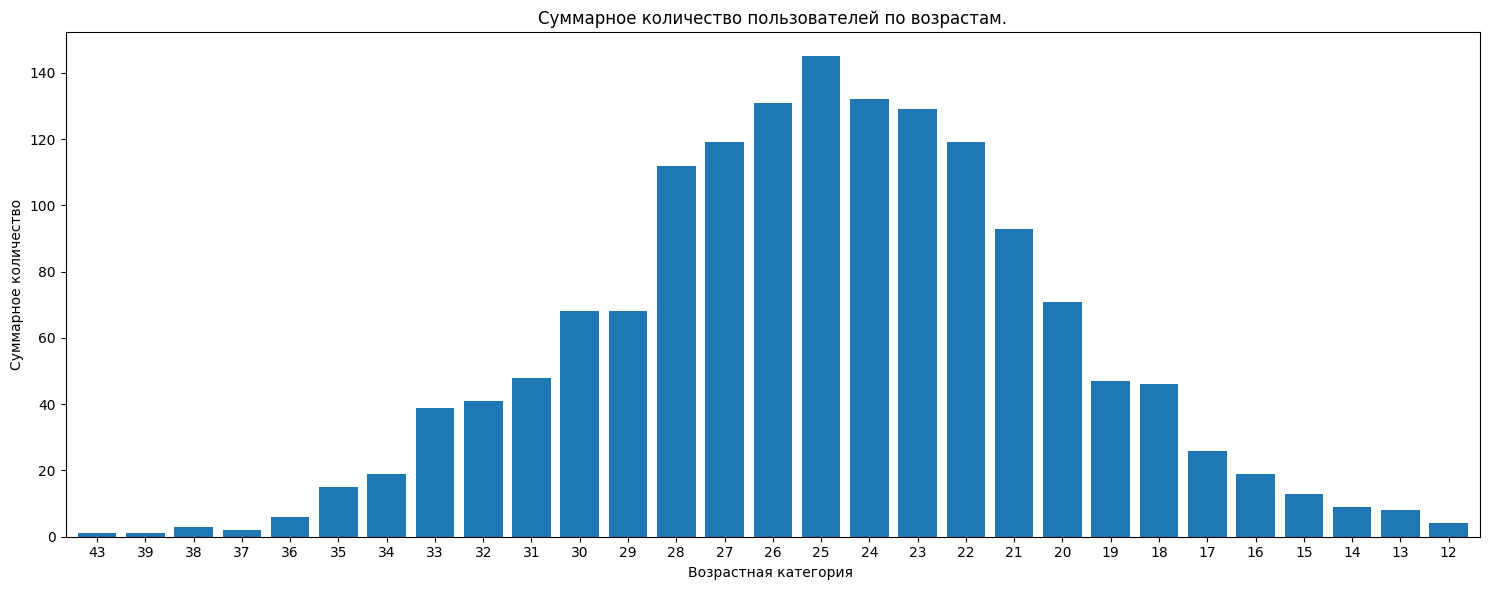

In [ ]:
# Строим график сформированной таблицы выше.
table_for_age_of_clients.plot(x='age',
                              y='user_id',
                              kind='bar',
                              figsize=(15, 6),
                              width=0.8,
                              legend=False,
                              title='Суммарное количество пользователей по возрастам.'
                             )

plt.xticks(rotation=0)

plt.xlabel('Возрастная категория ')
plt.ylabel('Суммарное количество')

plt.tight_layout()
plt.show()

График имеет форму нормального распределения, с пиком в возрастной группе 21–28 лет. В датасете также есть данные о пользователях младше 18 лет, что требует дополнительного внимания.

### Посмотрим на расстояние, которое пользователь преодолел за одну поездку.

In [ ]:
# Посмотрим сводную статистику длительности поездок в метрах.
data_rides['distance'].describe()

,distance
count,18068.000000
mean,3070.659992
std,1116.831222
min,0.860000
25%,2543.227500
50%,3133.610000
75%,3776.220000
max,7211.010000


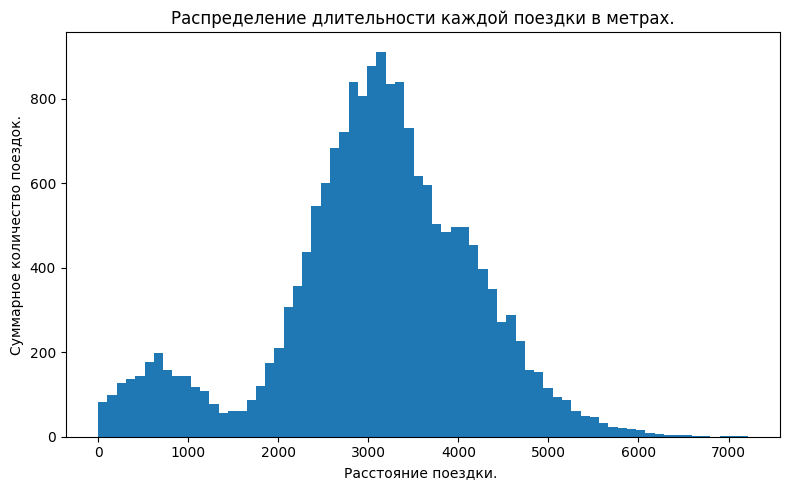

In [ ]:
# Построим график распределения длительностей поездок.
data_rides.plot(kind='hist',
                y='distance',
                bins=70,
                figsize=(8,5),
                legend=False,
                histtype='bar',
                title='Распределение длительности каждой поездки в метрах.'

               )

plt.xlabel('Расстояние поездки. ')
plt.ylabel('Суммарное количество поездок.')

plt.tight_layout()
plt.show()

По графику видно наличие двух пиков в районе 800 и 3200 метров пути. Также после расстояния 4200 метров в пути количество таких поездок резко сокращается.

### Посмотрим на продолжительность поездок.

In [ ]:
# Посмотрим сводную статистику продолжительности поездок.
data_rides['duration'].describe()

,duration
count,18068.000000
mean,17.805011
std,6.091051
min,0.500000
25%,13.597563
50%,17.678395
75%,21.724800
max,40.823963


Средняя длительность поездки составляет 17.8 минут, при этом основная масса значений лежит в диапазоне от 13.6 до 21.7 минут, с минимальным значением 0.5 и максимальным — 40.8 минут.

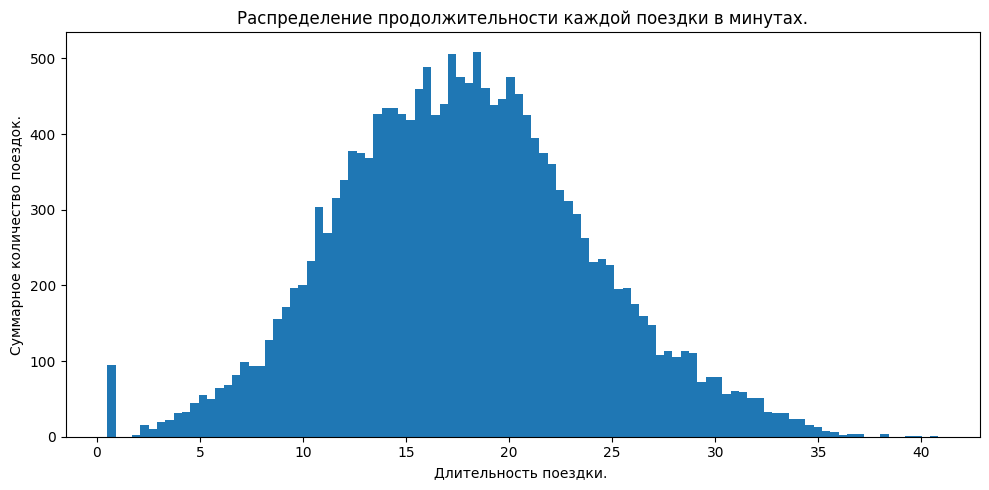

In [ ]:
# Построим график распределения продолжительности поездок в минутах.
data_rides.plot(kind='hist',
                y='duration',
                bins=100,
                figsize=(10,5),
                legend=False,
                histtype='bar',
                title='Распределение продолжительности каждой поездки в минутах.'

               )

plt.xlabel('Длительность поездки. ')
plt.ylabel('Суммарное количество поездок.')

plt.tight_layout()
plt.show()

График распределения длительности каждой поездки равномерен, смущает всплеск поездок в районе минут.

In [ ]:
#Подсчитаем количество пользователей, длительность поездки которых была меньше 2 минут.

data_rides.query('duration <=2').groupby(by='user_id')['date'].count().reset_index()['user_id'].count()

np.int64(90)

Это значение составляет 5,7 процента от общей выборки в таблице пользователи.

## Шаг 4. Объединение данных

### Объединим данные о пользователях, поездках и подписках в один датафрейм.

In [ ]:
merged_df = pd.merge(data_users, data_rides, on='user_id', how='left')

In [ ]:
merged_df_sum = pd.merge(merged_df, data_subscriptions, on='subscription_type', how='left')

In [ ]:
#Посмотрим на получившийся датафрейм, состоящий из трёх таблиц.
merged_df_sum

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.92,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.59,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.16,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.78,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.69,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.10,19.822962,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.42,21.409799,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.19,18.435051,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.31,16.674362,2021-11-27,11,8,50,0


In [ ]:
# Проверим полученный датафрейм на пропуски.
print(merged_df_sum.isna().sum())

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64


Объединение прошло без проблем, пропусков нет.

### Создадим датафрейм с данными о пользователях с подпиской.

In [ ]:
merged_df_sum_ultra = merged_df_sum.query('subscription_fee == 199')

In [ ]:
merged_df_sum_ultra

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.92,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.59,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.16,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.78,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.69,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
6495,699,Оксана,22,Москва,ultra,3973.05,24.671163,2021-08-29,8,6,0,199
6496,699,Оксана,22,Москва,ultra,3288.70,15.892886,2021-09-12,9,6,0,199
6497,699,Оксана,22,Москва,ultra,3076.16,14.389525,2021-09-26,9,6,0,199
6498,699,Оксана,22,Москва,ultra,4707.85,15.839579,2021-10-17,10,6,0,199


Построим графики

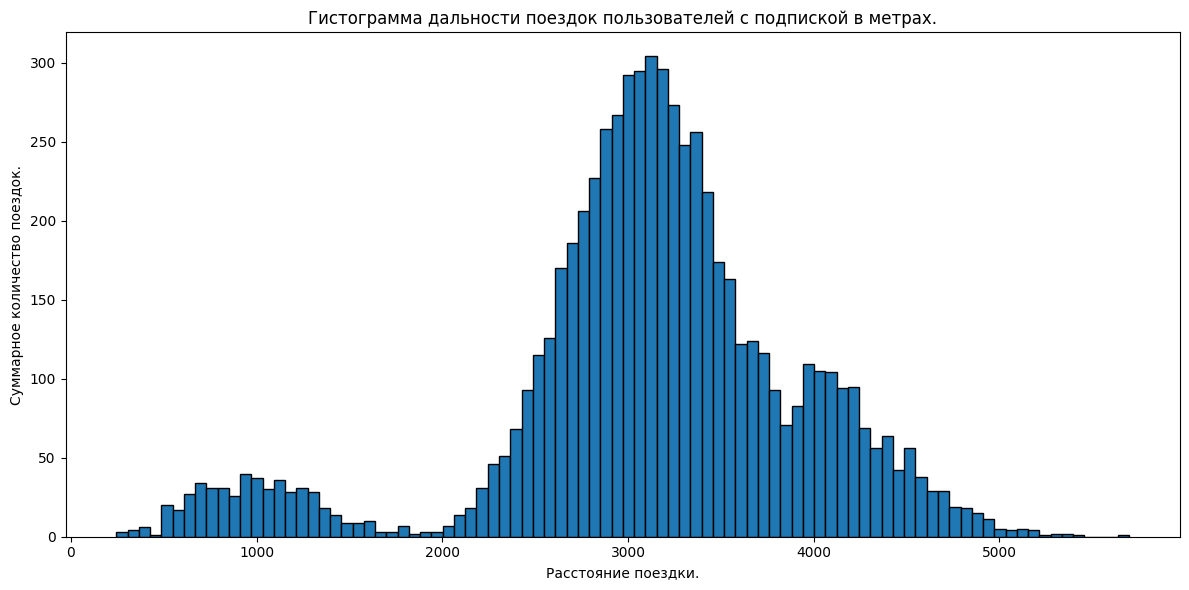

In [ ]:
# Гистограмма распределения дальности поездок
plt.figure(figsize=(12, 6))
plt.hist(merged_df_sum_ultra['distance'], bins=90 , edgecolor='black')

plt.title('Гистограмма дальности поездок пользователей с подпиской в метрах.')

plt.xlabel('Расстояние поездки.')
plt.ylabel('Суммарное количество поездок.')

plt.tight_layout()
plt.show()

Среди пользователей, оформивших подписку, можно выделить три категории. Первая группа совершает поездки на расстояния от 500 до 1500 метров, их немного. Вторая группа проезжает от 2500 до 3500 метров, а третья — от 3800 до 4200.

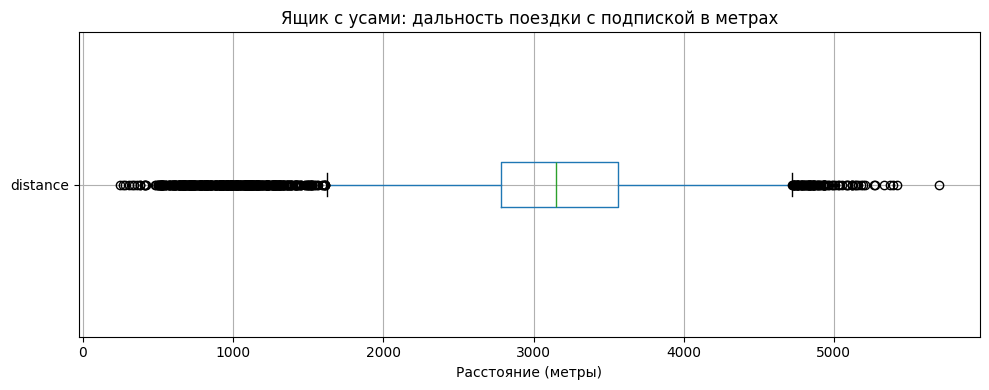

In [ ]:
# Горизонтальный боксплот, дальность поездки в метрах.
merged_df_sum_ultra.boxplot(column='distance', vert=False, figsize=(10, 4))

# Настройки отображения
plt.title('Ящик с усами: дальность поездки с подпиской в метрах')
plt.xlabel('Расстояние (метры)')
plt.grid(True)
plt.tight_layout()
plt.show()

Средняя продолжительность поездки для пользователей с подпиской составляет 3200. Все значения, которые не попадают в диапазон от 1600 до 4700, считаются отклонениями.

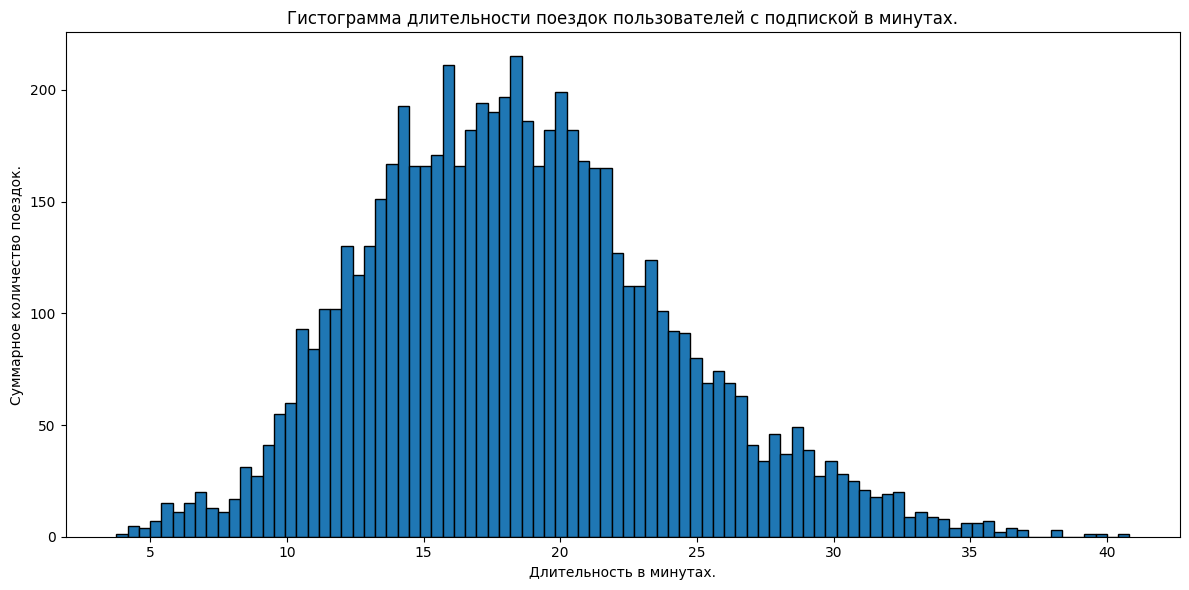

In [ ]:
# Гистограмма распределения длительности поездок.
plt.figure(figsize=(12, 6))
plt.hist(merged_df_sum_ultra['duration'], bins=90 , edgecolor='black')

plt.title('Гистограмма длительности поездок пользователей с подпиской в минутах.')

plt.xlabel('Длительность в минутах.')
plt.ylabel('Суммарное количество поездок.')

plt.tight_layout()
plt.show()

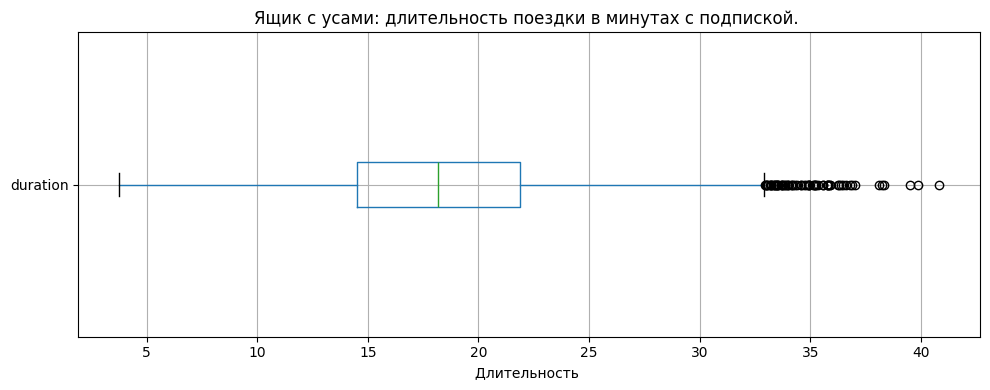

In [ ]:
# Горизонтальный боксплот, длительность поездки в минутах.
merged_df_sum_ultra.boxplot(column='duration', vert=False, figsize=(10, 4))

plt.title('Ящик с усами: длительность поездки в минутах с подпиской. ')
plt.xlabel('Длительность ')

plt.grid(True)

plt.tight_layout()
plt.show()

Средняя продолжительность поездки пользователя с подпиской — 18 минут.

### Создайте датафрейм с данными о пользователях без подписки.

In [ ]:
merged_df_sum_free = merged_df_sum.query('subscription_fee == 0')

In [ ]:
merged_df_sum_free

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.69,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.93,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.43,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.91,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.38,17.427673,2021-02-14,2,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.10,19.822962,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.42,21.409799,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.19,18.435051,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.31,16.674362,2021-11-27,11,8,50,0


Построим графики

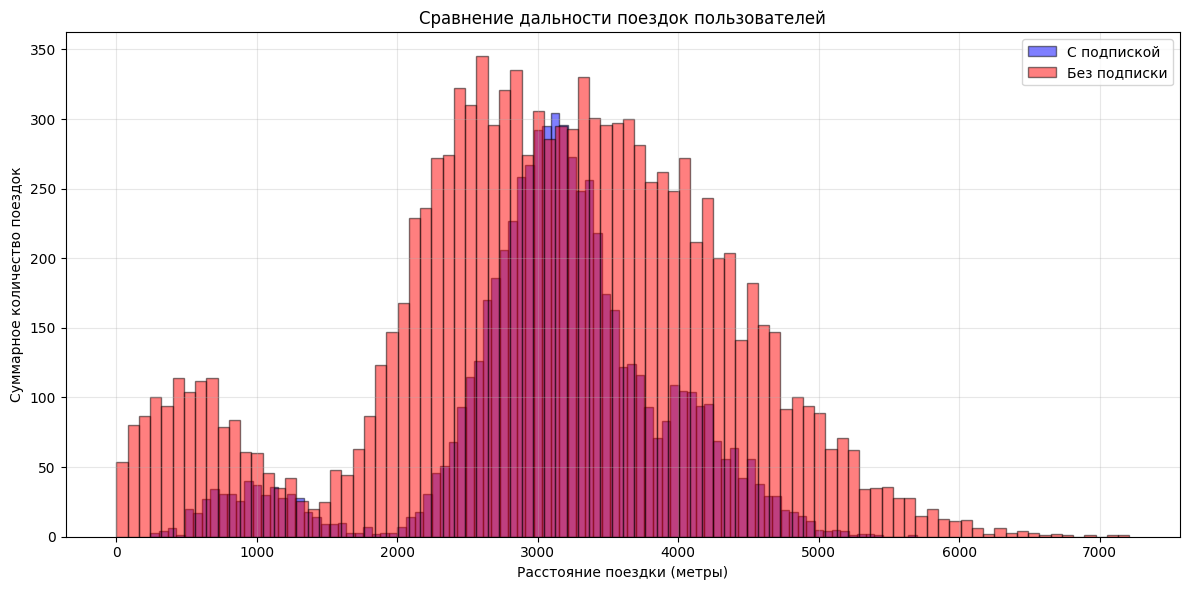

In [ ]:
# Построим графики с наложениями графиков пользователей с подпиской и без для параметра дальность поездки.
plt.figure(figsize=(12, 6))

# Гистограмма для пользователей с подпиской
plt.hist(merged_df_sum_ultra['distance'], bins=90, edgecolor='black',
         alpha=0.5, label='С подпиской', color='blue')

# Гистограмма для пользователей без подписки
plt.hist(merged_df_sum_free['distance'], bins=90, edgecolor='black',
         alpha=0.5, label='Без подписки', color='red')

# Оформление
plt.title('Сравнение дальности поездок пользователей')
plt.xlabel('Расстояние поездки (метры)')
plt.ylabel('Суммарное количество поездок')
plt.legend()          # Легенда для различения групп
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Среди пользователей, не оформивших подписку, можно выделить две категории: тех, кто проезжает в среднем 800 метров, и тех, кто проезжает в среднем 3200 метров. Первая категория более многочисленна, а вторая — менее многочисленна по сравнению с пользователями, оформившими подписку.

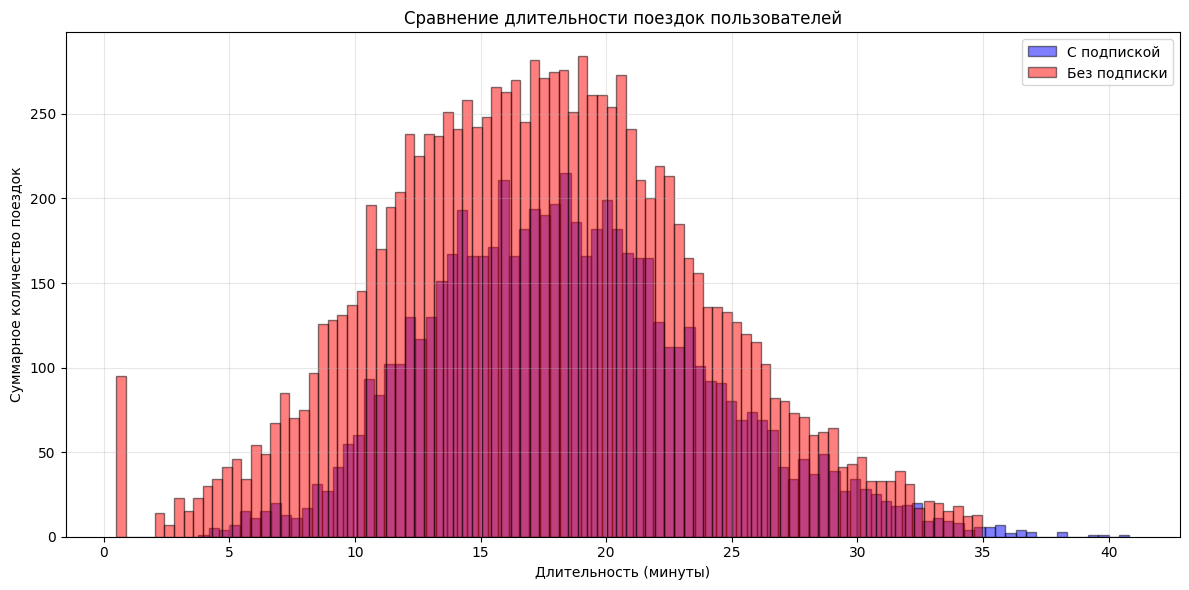

In [ ]:
# Построим графики с наложениями графиков пользователей с подпиской и без для параметра длительность поездоки.
plt.figure(figsize=(12, 6))

# Гистограмма длительности: с подпиской
plt.hist(merged_df_sum_ultra['duration'], bins=90, edgecolor='black',
         alpha=0.5, label='С подпиской', color='blue')

# Гистограмма длительности: без подписки
plt.hist(merged_df_sum_free['duration'], bins=90, edgecolor='black',
         alpha=0.5, label='Без подписки', color='red')

# Оформление
plt.title('Сравнение длительности поездок пользователей')
plt.xlabel('Длительность (минуты)')
plt.ylabel('Суммарное количество поездок')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

График распределения продолжительности поездок без подписки выглядит более равномерным по сравнению с графиком распределения продолжительности поездок в общем массиве данных. Кроме того, есть поездки, которые длятся около минуты.

#### Выводы по разделу.




Пользователи с подпиской совершают в среднем более длинные поездки (около 3200 м и 18 минут), при этом у них выражены три группы по расстоянию, тогда как пользователи без подписки чаще проезжают короткие дистанции (около 800 м), а распределение их поездок более равномерное, включая даже очень короткие поездки около минуты.

## Шаг 5. Подсчёт выручки

### Создадим датафрейм с агрегированными данными о поездках.

In [ ]:
# Посмотрим на датафрейм, получившийся в процессе объединения таблиц.
merged_df_sum

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.92,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.59,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.16,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.78,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.69,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.10,19.822962,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.42,21.409799,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.19,18.435051,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.31,16.674362,2021-11-27,11,8,50,0


In [ ]:
# Произведем округление длительности каждой поездки
merged_df_sum['duration'] = np.ceil(merged_df_sum['duration'])

In [ ]:
# Посмотрим на произведенное округление.
merged_df_sum.head(5)

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.92,26.0,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.59,16.0,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.16,7.0,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.78,19.0,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.69,27.0,2021-08-28,8,6,0,199


In [ ]:
# Выполним вычисления, которые требуются по заданию.
merged_df_sum_groupby = merged_df_sum.groupby(['month','user_id'],
                                              as_index=False).agg({'distance':'sum',
                                                                   'date':'count',
                                                                   'duration':'sum',
                                                                   'minute_price'    : 'mean',
                                                                   'start_ride_price': 'mean',
                                                                   'subscription_fee': 'mean'})

In [ ]:
# Получившаяся таблица
merged_df_sum_groupby

,month,user_id,distance,date,duration,minute_price,start_ride_price,subscription_fee
0,1,1,7027.51,2,42.0,6.0,0.0,199.0
1,1,3,3061.78,1,13.0,6.0,0.0,199.0
2,1,5,3914.65,1,13.0,6.0,0.0,199.0
3,1,7,6478.08,2,28.0,6.0,0.0,199.0
4,1,12,3577.15,1,33.0,6.0,0.0,199.0
...,...,...,...,...,...,...,...,...
11326,12,1525,4597.85,1,34.0,8.0,50.0,0.0
11327,12,1526,3644.12,1,23.0,8.0,50.0,0.0
11328,12,1528,3998.57,1,11.0,8.0,50.0,0.0
11329,12,1532,6111.89,2,42.0,8.0,50.0,0.0


In [ ]:
# Произведем проверку на пропуски в созданной таблице
merged_df_sum_groupby.isna().sum()

,0
month,0
user_id,0
distance,0
date,0
duration,0
minute_price,0
start_ride_price,0
subscription_fee,0


Пропусков в полученном датасете нет.

In [ ]:
# Рассчитаем прибыль, полученную от каждого клиента за каждый месяц.
merged_df_sum_groupby['revenue'] = merged_df_sum_groupby['date'] * merged_df_sum_groupby['start_ride_price'] +  merged_df_sum_groupby['duration'] * merged_df_sum_groupby['minute_price'] + merged_df_sum_groupby['subscription_fee']

In [ ]:
merged_df_sum_groupby

,month,user_id,distance,date,duration,minute_price,start_ride_price,subscription_fee,revenue
0,1,1,7027.51,2,42.0,6.0,0.0,199.0,451.0
1,1,3,3061.78,1,13.0,6.0,0.0,199.0,277.0
2,1,5,3914.65,1,13.0,6.0,0.0,199.0,277.0
3,1,7,6478.08,2,28.0,6.0,0.0,199.0,367.0
4,1,12,3577.15,1,33.0,6.0,0.0,199.0,397.0
...,...,...,...,...,...,...,...,...,...
11326,12,1525,4597.85,1,34.0,8.0,50.0,0.0,322.0
11327,12,1526,3644.12,1,23.0,8.0,50.0,0.0,234.0
11328,12,1528,3998.57,1,11.0,8.0,50.0,0.0,138.0
11329,12,1532,6111.89,2,42.0,8.0,50.0,0.0,436.0


## Шаг 6. Проверка гипотез

### Выясним, тратят ли пользователи с подпиской больше времени на поездки.

Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверьте гипотезу. Используйте исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

Нулевая и альтернативная гипотезы:</font><br>
Гипотеза Н0: средняя продолжительность поездок с подпиской и без равна(q_0 = q_1). </font><br>
Гипотеза Н1: средняя продолжительность поездок с подпиской больше, чем без подписки (q_0 > q_1). </font><br>


In [ ]:
alpha = 0.05 # уровень статистической значимости

# Проведем правосторонний t-тест для двух независимых выборок.
results = stats.ttest_ind(merged_df_sum_ultra['duration'], merged_df_sum_free['duration'], alternative='greater')

print('p-значение:', results.pvalue)


if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-значение: 1.2804098316645618e-34
Отвергаем нулевую гипотезу


Вывод: среднее время в пути для пользователей с подпиской, возможно, больше, чем для пользователей без подписки.

In [ ]:
# Проверка полученного вывода.
print('Среднее время поездки пользователей c подпиской:', round(merged_df_sum_ultra['duration'].mean(),2))
print('Среднее время поездки пользователей без подписки:', round(merged_df_sum_free['duration'].mean(),2))

Среднее время поездки пользователей c подпиской: 18.54
Среднее время поездки пользователей без подписки: 17.39


### Проверим гипотезу о длительности поездки пользователей с подпиской.

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверьте гипотезу и сделайте выводы.

Нулевая и альтернативная гипотезы:</font><br>
Гипотеза Н0: средняя длительность (в метрах) поездок с подпиской меньше или равна 3130 (q_0 <= 3130). </font><br>
Гипотеза Н1: средняя длительность (в метрах) поездок с подпиской больше  3130 (q_0 > 3130). </font><br>

In [ ]:
value = 3130 # Оптимальное расстояние с точки зрения износа самоката.

alpha = 0.05 # уровень статистической значимости

# Проведем левосторонний t-тест для одной выборки.
results = stats.ttest_1samp(merged_df_sum_ultra['distance'], value, alternative='greater')

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 0.9195362605842414
Не получилось отвергнуть нулевую гипотезу


In [ ]:
print('Среднее расстояние пользователя с подпиской:', merged_df_sum_ultra['distance'].mean())
print('Среднее расстояние пользователя без подписки:', merged_df_sum_free['distance'].mean())


Среднее расстояние пользователя с подпиской: 3115.445430769231
Среднее расстояние пользователя без подписки: 3045.495283540802


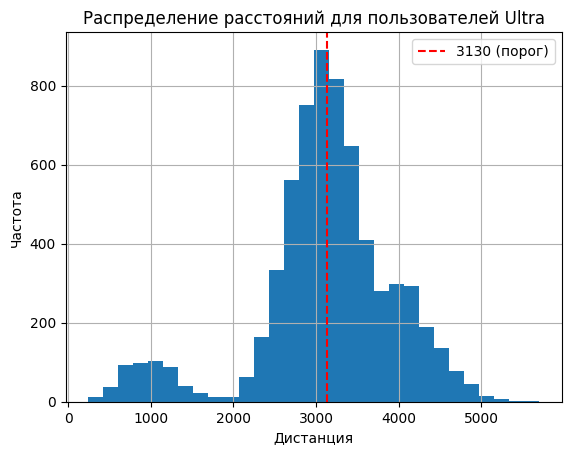

In [ ]:
merged_df_sum_ultra['distance'].hist(bins=30)
plt.axvline(value, color='red', linestyle='--', label='3130 (порог)')
plt.xlabel('Дистанция')
plt.ylabel('Частота')
plt.title('Распределение расстояний для пользователей Ultra')
plt.legend()
plt.show()

После проведенного t-тестирования не нашлось достаточных оснований, чтобы отвергнуть нулевую гипотезу. Расчеты среднего значения лишь подтверждают t-тест.

### Проверим гипотезу о длительности поездки пользователей с подпиской.

Проверьте гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. Сделайте вывод.

Нулевая и альтернативная гипотезы:</font><br>
Гипотеза Н0: Выручка от пользователей с подпиской и без помесяцам равны. (q_0 = q_1). </font><br>
Гипотеза Н1: Выручка от пользователей по месяцам с подпиской выше, чем и без подписки.(q_0 > q_1). </font><br>

In [ ]:
# Сформируем выборки для анализа.
merged_df_sum_groupby_Ultra= merged_df_sum_groupby.query('subscription_fee == 199')
merged_df_sum_groupby_free= merged_df_sum_groupby.query('subscription_fee == 0')


In [ ]:
alpha = 0.05 # уровень статистической значимости

# Проведем правосторонний t-тест для двух независимых выборок.
results = stats.ttest_ind(merged_df_sum_groupby_Ultra ['revenue'], merged_df_sum_groupby_free ['revenue'], alternative='greater')

print('p-значение:', results.pvalue)


if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-значение: 1.8850394384715216e-31
Отвергаем нулевую гипотезу


Вывод: помесячная выручка от пользователей с подпиской, возможно, больше.

In [ ]:
# Проверка полученного вывода.
print('Средняя помесячная выручка от пользователи с подпиской:', round(merged_df_sum_groupby_Ultra ['revenue'].mean(),2))
print('Средняя помесячная выручка от пользователи без подписки:', round(merged_df_sum_groupby_free ['revenue'].mean(),2))

Средняя помесячная выручка от пользователи с подпиской: 362.79
Средняя помесячная выручка от пользователи без подписки: 328.64


### Проверим гипотезу о числе обращений в техподдержку на пользователя.

 Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

 Ответ:
 Для проверки гипотезы о равенстве средних значений до и после обновления используется тест для зависимых выборок. В scipy.stats.ttest_rel() передаются два набора данных (до и после) и параметр alternative='greater' для правосторонней гипотезы:

1. H0: средние до и после равны.
2. H1: среднее до изменения больше среднего после.

* Два набора зависимых данных.
* Гипотеза о равенстве средних.
* scipy.stats.ttest_rel с аргументами: данные до и после, alternative='greater'.

## Шаг 7. Распределения

### Определим, какое минимальное число промокодов необходимо отправить.

 Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж.
Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов.

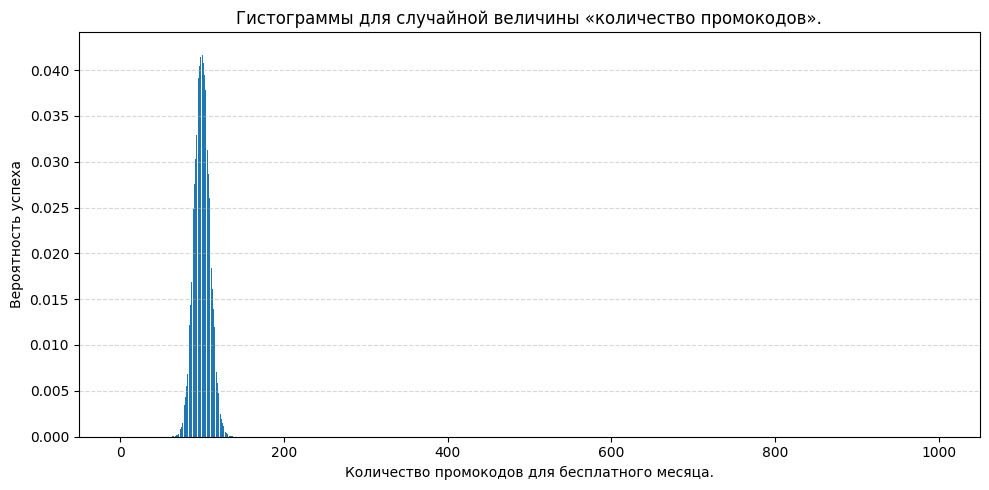

In [ ]:
# определим примерный диапазон значений биномиального распределения графиком
n = 1000
p = 0.1
distr = []

for k in range(0, n + 1):
    choose = factorial(n) / (factorial(k) * factorial(n - k))
    prob = choose * p**k * (1 - p)**(n - k)
    distr.append(prob)


plt.figure(figsize=(10, 5))
plt.bar(range(0, n + 1), distr)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.xlabel('Количество промокодов для бесплатного месяца.')
plt.ylabel('Вероятность успеха')

plt.title('Гистограммы для случайной величины «количество промокодов».')
plt.tight_layout()
plt.show()




В диапазоне (n-500, n+500) определим минимальное количество промокодов, чтобы вероятность не выполнить план была не больше 5%.

In [ ]:
for n in range (500,1500):
    if binom.cdf(99, n, p) < 0.05:
        print("Минимальное число промокодов:", n)
        break

Минимальное число промокодов: 1161


Вывод:
Для акции раздачи промокодов с целью получения не менее 100 продлений подписок, с вероятностью невыполнения не больше 5%, нужно сделать рассылку не менее 1161 промокодов.

### Построим график и определим вероятность.

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

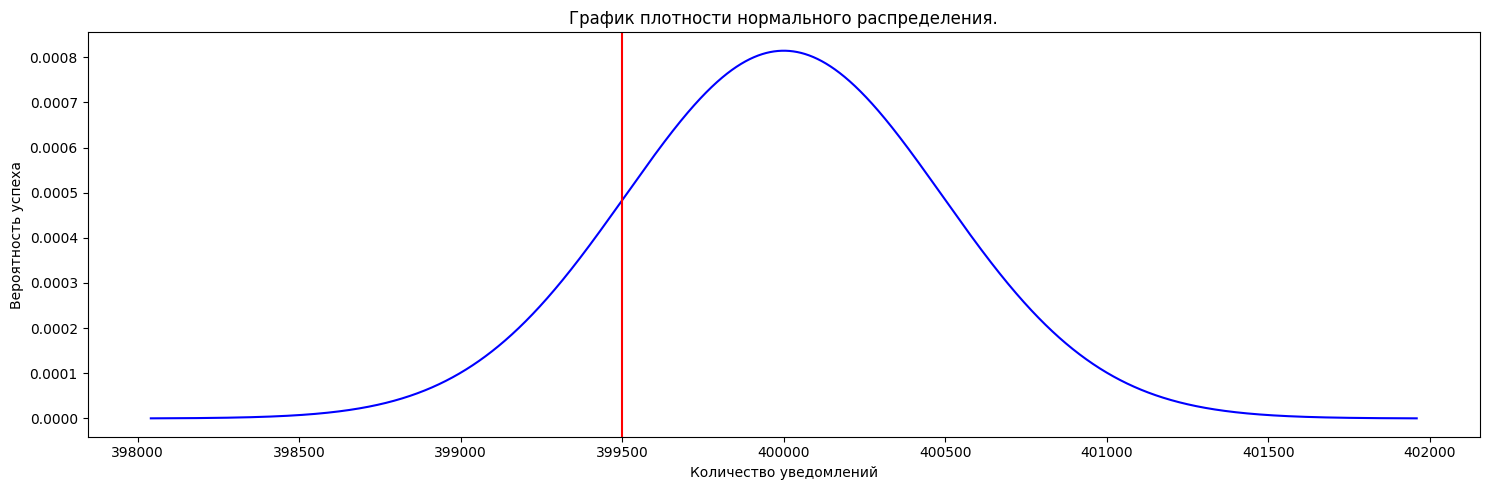

Вероятность что push-уведомления откроют не более 399,5 тыс. пользователей: 0.15


In [ ]:
# Аппроксимируем биномиальное распределение нормальным
# задаём параметры биномиального распределения
n = 1000000
p = 0.4

mu = n * p
sigma = sqrt(n * p * (1 - p))
# задаём нормальное распределение
distr = stats.norm(mu, sigma)

x = 399500

# считаем вероятность получить значение, равное x или меньше
result = distr.cdf(x)

# Построение графика
arange = np.arange(
        (mu - 4 * sigma),
        (mu + 4 * sigma),
        1
    )
plt.figure(figsize=(15, 5))
plt.plot(arange, stats.norm.pdf(arange, mu, sigma), 'b-')
plt.axvline(x=x, color='red')


plt.xlabel('Количество уведомлений')
plt.ylabel('Вероятность успеха')

plt.title('График плотности нормального распределения.')

plt.tight_layout()
plt.show()

print('Вероятность что push-уведомления откроют не более 399,5 тыс. пользователей:',  round(result, 2))

 Вывод: В условиях акции рассылки 1 млн. push-уведомлений вероятность что откроют их не более 399,5 тыс. пользователей - 15%

## Общий вывод

### 1. Общая информация о данных

В ходе проекта проанализированы данные о 1565 пользователях и 18 068 поездках. Проведена очистка, предобработка и базовый анализ трёх таблиц: пользователи, поездки и тарифы. Пропущенных значений и дубликатов не обнаружено, типы данных корректны, выполнено преобразование дат и добавление производных признаков.

### 2. География пользователей

Распределение пользователей по городам равномерное:

- Максимум — Пятигорск (219 пользователей).
- Минимум — Москва (168 пользователей).

Разброс между городами небольшой, что говорит о сбалансированном региональном присутствии сервиса.

### 3. Тип подписки и поведение пользователей

- Клиентов без подписки на 8% больше, чем с подпиской (54% против 46%).
- Пользователи с подпиской совершают более длительные и дальние поездки:
    - Средняя длительность: 18,54 мин (против 17,39 мин без подписки).
    - Средняя дистанция: 3115 м (против 3045 м без подписки).
- Средняя помесячная выручка также выше у подписчиков: 362,79 против 328,64.

Статистические проверки подтвердили значимость различий между группами с вероятностью 5%.

### 4. Анализ поездок

**По расстоянию:**

- Гистограмма выявила два пика: около 800 м и 3200 м.
- После 4200 м наблюдается резкое снижение количества поездок.

**По длительности:**

- Распределение визуально равномерное.
- Присутствует аномальный всплеск в районе одной минуты (примерно 5,7% выборки), требующий дополнительной проверки (возможны технические сбои или особенности тарификации).

Выявленные паттерны указывают на два типичных сценария использования самокатов:

- Короткие поездки в пределах района.
- Средние поездки (например, до работы или в центр города).

### 5. Бизнес-расчёты

- Для получения 100 продлений подписки через акцию с промокодами потребуется минимум 1161 промокод.
- При рассылке 1 млн push-уведомлений с вероятностью 15% откроют не более 150 тыс. (при базе в 399,5 тыс. пользователей).

### 6. Рекомендации

1. Продвижение подписок — активные маркетинговые кампании, привилегии для подписчиков и сезонные акции для конвертации пользователей без подписки.
2. Оптимизация парка самокатов — использование данных о географии и паттернах поездок для эффективного размещения самокатов.
3. Стимулирование интенсивного использования — программы лояльности с бонусами и скидками для активных пользователей.
4. Гибкие тарифы — внедрение краткосрочных подписок и пакетных предложений для разных сегментов аудитории.
5. Улучшение аналитики — постоянный мониторинг данных для точного прогнозирования спроса и корректировки стратегий.

### 7. Итог

Подписка повышает ценность клиента за счёт более частых, длительных и дальних поездок, а также приносит больше выручки. Данные позволяют точно настраивать маркетинговые и продуктовые решения, что создаёт потенциал для роста бизнеса и улучшения пользовательского опыта.